In [ ]:
import re
with open("nalgae.txt", "r", encoding="utf-8") as f:
    text = f.read().replace(" ", "_")
text = re.sub(r'[^0-9가-힣.,!?_\-()(···)"\'\n]', ' ', text)
len(text)

21457

In [248]:
len(text)/len(set(text))

26.82125

In [272]:
bag_of_word = list(set(text))
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["안"]]

'안'

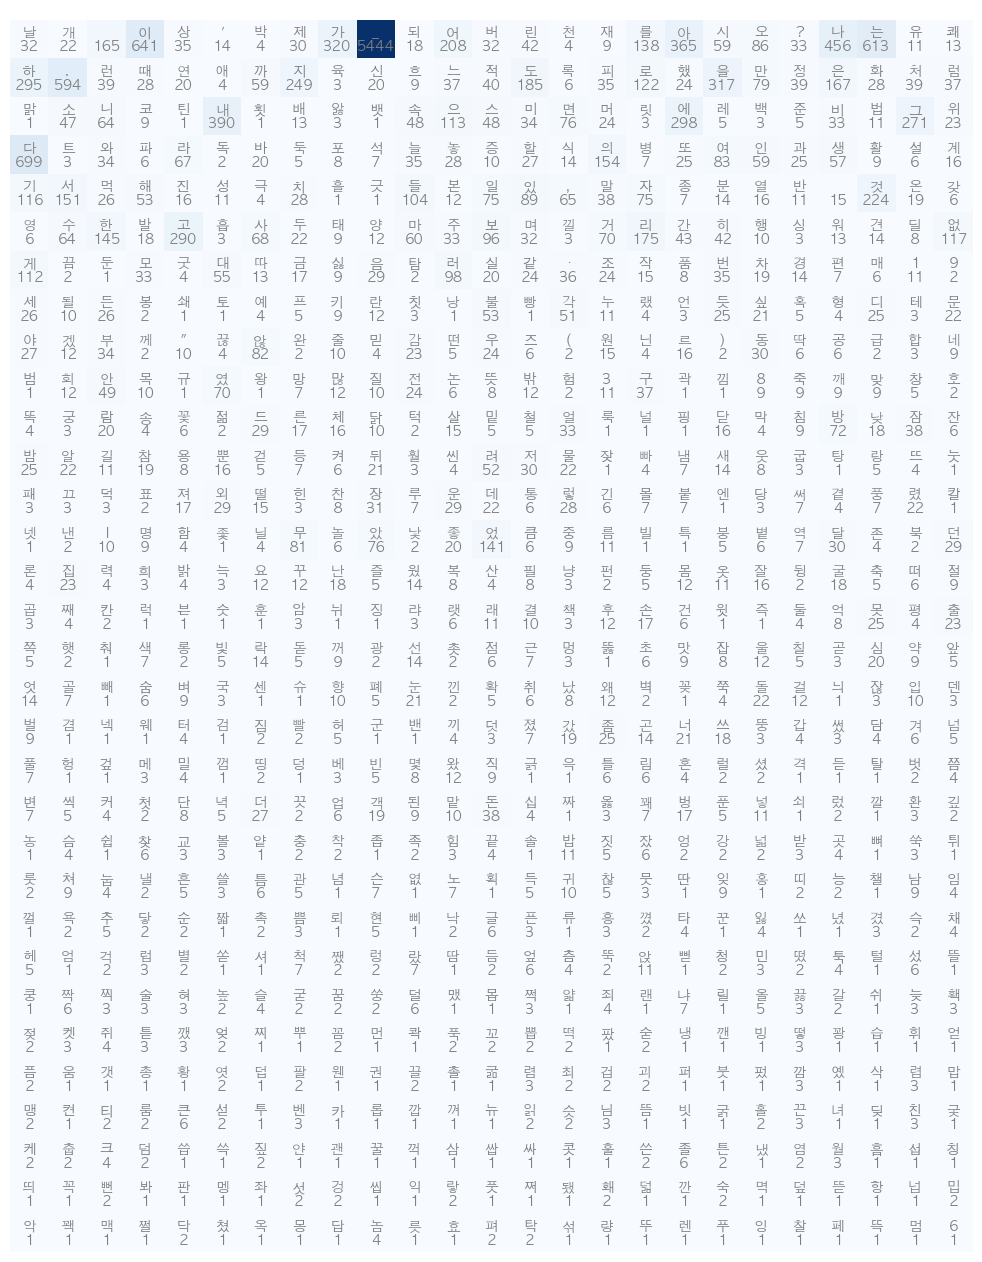

In [284]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import findfont, FontProperties
# print(findfont(FontProperties(family=['AppleGothic'])))
counter = Counter(text)
keys = list(counter.keys())

img = np.array(list(counter.values())).reshape(32, 25)
plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(img, cmap="Blues")
plt.axis("off")
for i in range(32):
    for j in range(25):
        chstr = keys[i*25+j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, str(counter[chstr]), ha="center", va="top", color="gray")

'안'

In [339]:
def make_chunks(data, n=5):
    for ptr in range(0, len(data)-n-1):
        yield data[ptr:ptr+n+1]

n = 3
chunks = [chunk for chunk in make_chunks(text, 3)]

In [340]:
chunks[10:13]

['제가_되', '가_되어', '_되어_']

In [124]:
len(chunks)

21441

In [125]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [643, 746, 795, 795]
String: 날개




In [341]:
import math
print("Total tokens:", len(stoi))
print("Current Entropy:", math.log2(len(stoi)))

Total tokens: 800
Current Entropy: 9.643856189774725


In [348]:
import random

def beautiful_f(x):
    return random.randint(0, total_tokens)

def generate(x, function, max_length=100, **kwrgs):
    for i in range(len(x), max_length):
        x += stringfy([function(x[i-n:i], **kwrgs)])
    return x

chunk = chunks[0]
x = chunk[:n]
y = chunk[n]
print(generate(x, beautiful_f))

날개
의밥음미로벽껴니븐끔통혼힌옷딜희것탈채떴격잉셨설충막긋겅8좀횟송찰씩칸타좀밉요맹해둔슷척흥름낀
걷질슈푹넥땀딱읽붙번빵패꾼슥엎걸벌썼걷르까틴믿켓직슨였슈리렸칭있웨챌홀털높완낀흠바순겸뚫즐험숨너넙


# 오차 역전파에 대해서 알아보자.

In [349]:
import torch
w1_torch = torch.randn(3, 2, requires_grad=True)
b1_torch = torch.randn(3, requires_grad=True)
x_torch = torch.randn(2, requires_grad=True)
y = w1_torch @ x_torch + b1_torch
loss = y.sum()
loss.backward()
print("w1:",w1_torch.grad)
print("b1:",b1_torch.grad)
print("x:",x_torch.grad)

w1: tensor([[ 0.6169, -0.1997],
        [ 0.6169, -0.1997],
        [ 0.6169, -0.1997]])
b1: tensor([1., 1., 1.])
x: tensor([0.1785, 0.8539])


In [350]:
import numpy as np

x = x_torch.detach().numpy()
W1 = w1_torch.detach().numpy()
B1 = b1_torch.detach().numpy()
y = W1 @ x + B1

In [351]:
dydW1 = np.stack([x, x, x], axis=0)
dydB1 = np.ones(3)
dydX = np.sum(W1, axis=0)
print("w1:",dydW1)
print("b1:",dydB1)
print("x:",dydX)

w1: [[ 0.6168744  -0.19965301]
 [ 0.6168744  -0.19965301]
 [ 0.6168744  -0.19965301]]
b1: [1. 1. 1.]
x: [0.17854549 0.853861  ]


In [358]:
import numpy as np

W = np.random.randn(1, n) / 100
B = np.zeros((1))

losses = []
for _ in range(100):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n] / total_tokens
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(chunk)

    y = W @ x + B
    error = np.sum((y-ground_truth) ** 2)
    print("Square Error:", error)
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = 2*(y-ground_truth)
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-2
    W -= lr * dEdW
    B -= lr * dEdB


그_꽃에
Square Error: 0.2449961801496849
그만_내
Square Error: 0.022177332994466347
앉아_어
Square Error: 0.04284511359152632
괴이한_
Square Error: 0.6645716791085523

나는_
Square Error: 0.5975573915396264
나케_와
Square Error: 0.631217993509969
.
쾌감
Square Error: 0.15935322256053044
보면_열
Square Error: 0.3292066406236679
남자가_
Square Error: 0.4023536327939106
_수는_
Square Error: 0.3613293583174077
드디어_
Square Error: 0.43259930972132365
_왜_내
Square Error: 0.014337894336629957
하나_골
Square Error: 0.03245011604280604
_것만_
Square Error: 0.412340340821194
듯_잠들
Square Error: 0.34412832480917743
듯싶소.
Square Error: 0.24849424971855377
다._비
Square Error: 0.019327524835303964
_타_주
Square Error: 0.005082773021375161
고_속이
Square Error: 0.02972312351652645
는_다시
Square Error: 0.19476046852396703
들고_그
Square Error: 0.16077187875938392
노기가_
Square Error: 0.20048767324071876
그랬는지
Square Error: 0.17219803372458217
_보내고
Square Error: 0.006366178243600753
닭은_이
Square Error: 0.011783612373882956
고_일어
Square Error: 0.02374506

Text(0.5, 0, 'epoch')

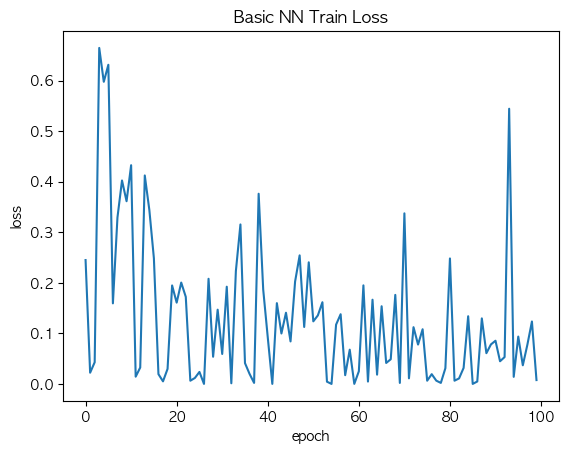

In [359]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic NN Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [360]:
def simple_linear(x, **kwrgs):
    x = np.array(tokenize(x)) / total_tokens
    y = kwrgs["W"] @ x + kwrgs["B"]
    return np.clip(np.ceil(y*total_tokens), 0, total_tokens-1)[-1]

generate("날개는 돋았", simple_linear, W=W, B=B)

'날개는 돋았상척천득규햇준둘케푸히히덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥덥'

In [362]:
it = list(set(generate("날개는 돋았", simple_linear, W=W, B=B)))
for char in it:
    print(stoi[char] / total_tokens) # 0.5를 출력하는 멍청이..

0.51
0.565
0.58
0.58125
0.93625
0.57375
0.5825
0.5675
0.80625
0.5775
0.1325
0.5875
0.215
0.5725
0.55875
0.93
0.57625
0.5075


Text(0.5, 1.0, 'weight distribution')

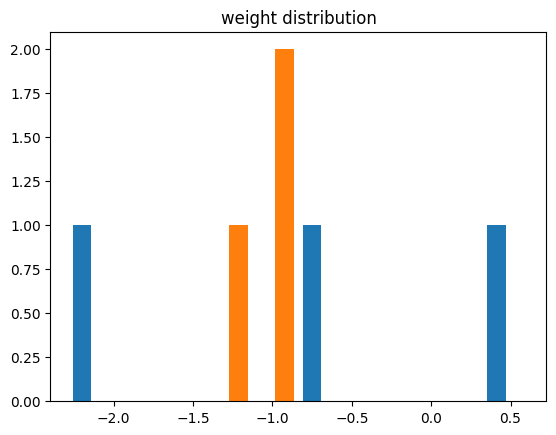

In [179]:
plt.hist(W1)
plt.title("weight distribution")

In [188]:
W = np.random.randn(total_tokens, n) / 100
B = np.zeros((total_tokens))

losses = []
for _ in range(1000):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n]
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(f"{chunk[:n]} -> {chunk[n]}")

    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    # print(softmaxed)
    error = -np.log2(softmaxed[ground_truth])
    print("Entropy Error:", error, "Prediction:", itos[np.argmax(softmaxed)])
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = softmaxed
    dEdy[ground_truth] -= 1
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-2
    W -= lr * dEdW
    B -= lr * dEdB

_안일 -> 한
Entropy Error: 9.601362273472388 Prediction: 았
그럼_ -> 외
Entropy Error: 9.67970346266816 Prediction: 한

그러 -> 나
Entropy Error: 9.653745702925772 Prediction: 한
서는_ -> 빨
Entropy Error: 9.621747297858668 Prediction: 한
_또_ -> 여
Entropy Error: 9.637990968575071 Prediction: 한
_생각 -> 하
Entropy Error: 9.626686160188664 Prediction: 한
지_않 -> 는
Entropy Error: 9.678181117580584 Prediction: 한
험하고 -> _
Entropy Error: 9.637273135312737 Prediction: 한
얼마간 -> _
Entropy Error: 9.604097590518094 Prediction: 한
다.
 -> 나
Entropy Error: 9.62409867151248 Prediction: _
굴과_ -> 그
Entropy Error: 9.616241272386462 Prediction: 한
리_뒹 -> 굴
Entropy Error: 9.62782404881566 Prediction: _
.
내 -> 객
Entropy Error: 9.618936740420454 Prediction: 한
다._ -> 오
Entropy Error: 9.65222703994404 Prediction: _
_좋았 -> 을
Entropy Error: 9.663637794388462 Prediction: 한
보내려 -> _
Entropy Error: 9.571567634862987 Prediction: _
_수밖 -> 에
Entropy Error: 9.595399580153932 Prediction: _
알고_ -> 한
Entropy Error: 9.589584368565848 Prediction

Text(0.5, 0, 'epoch')

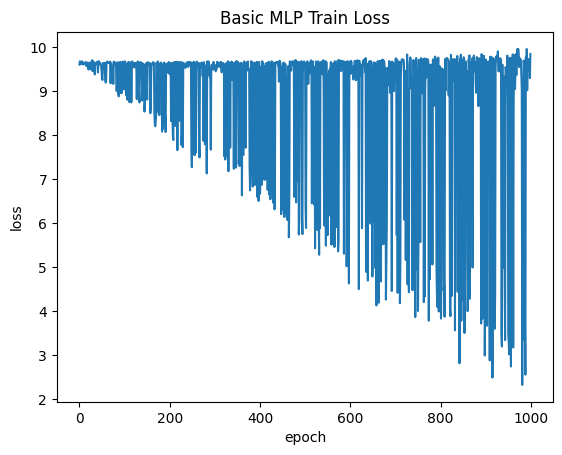

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic MLP Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [357]:
def logistic(x, W, B):
    x = np.array(tokenize(x)) / total_tokens
    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    return np.random.choice(len(softmaxed), p=softmaxed)

generate("날개는_돋았", logistic, W=W, B=B).replace(" ", "_")

'날개는_돋았붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓붓'

In [ ]:
emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
print(Emb[:2])
Emb[[1, 0, 1]]

[[ 0.02970286  0.48919849  0.90674236 -0.31576101 -1.04167382 -1.18143387
  -1.31191978 -0.40202356 -0.65590011  1.19113591]
 [-1.03475012  1.32370107 -0.80560645 -0.22259429  1.39900286 -1.91275453
   1.10168927 -0.30677326  0.34459843  1.52363338]]


array([[-1.03475012,  1.32370107, -0.80560645, -0.22259429,  1.39900286,
        -1.91275453,  1.10168927, -0.30677326,  0.34459843,  1.52363338],
       [ 0.02970286,  0.48919849,  0.90674236, -0.31576101, -1.04167382,
        -1.18143387, -1.31191978, -0.40202356, -0.65590011,  1.19113591],
       [-1.03475012,  1.32370107, -0.80560645, -0.22259429,  1.39900286,
        -1.91275453,  1.10168927, -0.30677326,  0.34459843,  1.52363338]])

In [ ]:
import tqdm

emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
W = np.random.randn(total_tokens, n*emb_size) / 100
B = np.zeros((total_tokens))

losses = []
small_batch = 32
# epoch
for epoch in tqdm.trange(10000):
    # parameter
    parameters = {
        "dEdW": np.zeros_like(W),
        "dEdB": np.zeros_like(B),
        "dEdEmb": np.zeros_like(Emb),
    }
    epoch_loss = 0.0
    # batch
    for i in range(small_batch):
        chunk = random.choice(chunks)
        ground_truth = tokenize(chunk)[n]
        indexs = tokenize(chunk)[:n]
        x = Emb[indexs].reshape(-1)

        y = W @ x + B
        exped = np.exp(y-y.max())
        softmaxed = exped / np.sum(exped, keepdims=False)
        loss = -np.log2(softmaxed[ground_truth])
        epoch_loss += loss

        dEdy = softmaxed
        dEdy[ground_truth] -= 1
        dEdW = dEdy[:, None] * x[None, :]
        dEdB = dEdy.copy()
        dEdX = W.T @ dEdy
        dEdEmb = np.zeros_like(Emb)
        dEdEmb[indexs] += dEdX.reshape(n, emb_size)
        parameters["dEdW"] += dEdW
        parameters["dEdB"] += dEdB
        parameters["dEdEmb"] += dEdEmb

    avg_loss = epoch_loss / small_batch
    if epoch % 50 == 0:
        pred = np.argmax(y)
        print(f"{chunk[:n]} -> {chunk[n]}")
        print("Entropy Error (avg):", avg_loss, "Prediction:", itos[pred])
        losses.append(avg_loss)

    # optimizer
    lr = 5e-3
    W -= lr * parameters["dEdW"] / small_batch
    B -= lr * parameters["dEdB"] / small_batch
    Emb -= lr * parameters["dEdEmb"] / small_batch

  0%|          | 2/10000 [00:00<13:55, 11.97it/s]

다._ -> 오
Entropy Error (avg): 9.612889423703761 Prediction: 친


  1%|          | 52/10000 [00:04<14:59, 11.06it/s]

신이란 -> _
Entropy Error (avg): 9.591963212716458 Prediction: 센


  1%|          | 102/10000 [00:08<14:51, 11.11it/s]

...

 99%|█████████▉| 9903/10000 [12:03<00:06, 15.54it/s]

버리고 -> _
Entropy Error (avg): 6.143214844802751 Prediction: _


100%|█████████▉| 9953/10000 [12:07<00:03, 13.19it/s]

지_않 -> 았
Entropy Error (avg): 6.29771762394857 Prediction: 을


100%|██████████| 10000/10000 [12:10<00:00, 13.69it/s]


In [324]:
# np.savez_compressed("simp.npz", W=W, B=B, Emb=Emb)
data = np.load("simp.npz")
W = data["W"]
B = data["B"]
Emb = data["Emb"]

Text(0.5, 0, 'epoch')

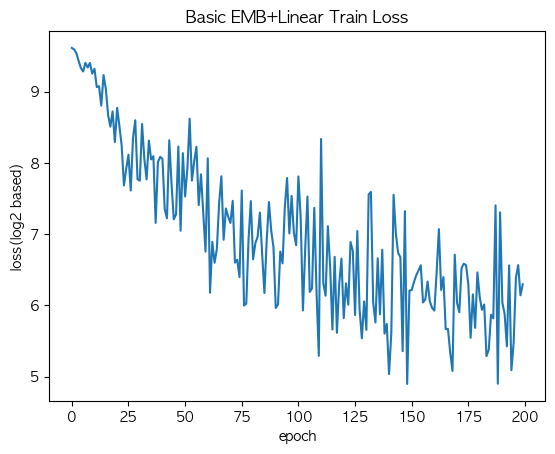

In [325]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic EMB+Linear Train Loss")
plt.ylabel("loss(log2 based)")
plt.xlabel("epoch")

In [337]:
def logistic(x):
    indexs = tokenize(x)
    x = Emb[indexs].reshape(-1)
    y = W @ x + B
    exped = np.exp((y-y.max()) / 0.5)
    softmaxed = exped / np.sum(exped, keepdims=False)
    return np.random.choice(len(softmaxed), p=softmaxed)
generate("박제가_되어버린_", logistic, max_length=50).replace(" ", "_")

'박제가_되어버린_아내는_내_가__아는다._나는다._그러._그는_마_이지_않이_아내지_내_이'

In [338]:
generate("슬픈_", logistic, max_length=50).replace(" ", "_")

'슬픈_아내__아는_내_이지_지_가_하하이_아내의_내_하충다._그는_것을_그고_아내는_것_아'

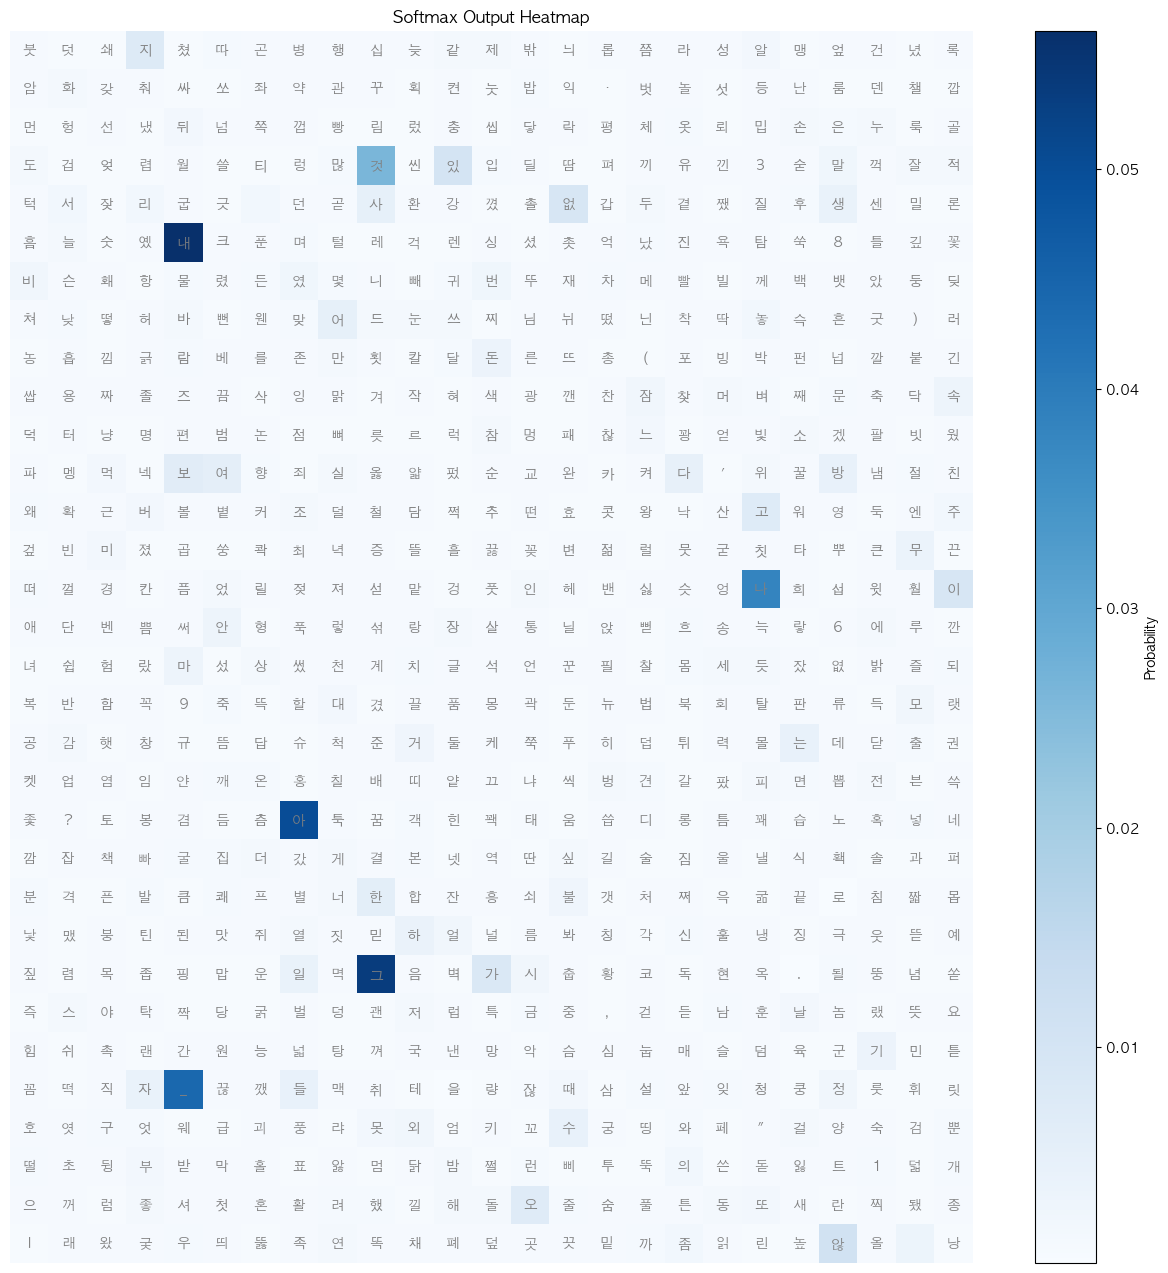

In [333]:
indexs = tokenize("감정_")
x = Emb[indexs].reshape(-1)
y = W @ x + B
exped = np.exp(y-y.max())
softmaxed = exped / np.sum(exped, keepdims=False)

plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(softmaxed.reshape(32, 25), cmap="Blues")
plt.colorbar(label="Probability")  # add this line
plt.title("Softmax Output Heatmap")
plt.axis("off")
for i in range(32):
    for j in range(25):
        chstr = itos[i*25+j]
        plt.text(j, i, chstr, ha="center", va="center", color="gray")
        # plt.text(j, i, f"{softmaxed[i*25+j]:.2f}", ha="center", va="top", color="gray")